<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# sklearn

In [41]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-deep-learning/refs/heads/main/day3/placement.csv')
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [42]:
m,n = df.shape
m,n

(100, 3)

In [43]:
placed = df["placed"]
col = placed.map({0:"red",1:"blue"})
col

,placed
0,blue
1,red
2,blue
3,blue
4,blue
...,...
95,red
96,blue
97,red
98,blue


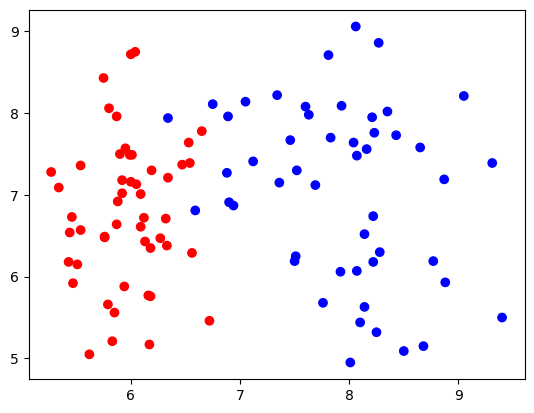

In [44]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'],df['resume_score'], c= col)
plt.show()

In [45]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [46]:
from sklearn.linear_model import Perceptron
p = Perceptron()
p.fit(X, y)

Perceptron()

In [47]:
p.score(X, y)

0.75

In [48]:
p.predict([X.iloc[0]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


array([1])

In [49]:
p.coef_, p.intercept_

(array([[ 40.26, -36.  ]]), array([-25.]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

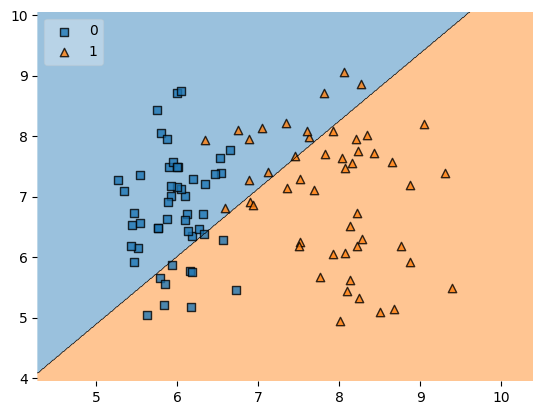

In [50]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.values, clf=p, legend=2)

# scratch (perceptron trick method)

In [51]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [52]:
for i in range(5):
    print(X[i], ":", y[i])

[ 0.19924745 -0.11697552] : 1
[-0.24882029 -0.73115232] : 1
[-0.3544904 -0.7081059] : 1
[-1.59086506 -2.01199214] : 0
[-0.20083951  1.63493163] : 1


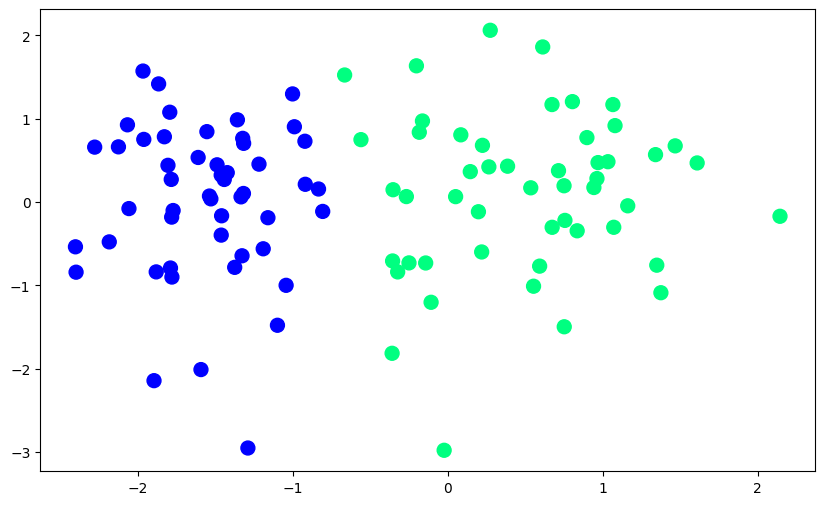

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [54]:
def unit_step(z):
    return 1 if z>0 else 0

In [55]:
def perceptron(X, y, a):
  rng = np.random.default_rng(2021)
  X = np.insert(X, 0, 1, axis=1)
  w = rng.random(3)

  for i in range(1000):
    j = np.random.randint(0, 100)
    y_hat = unit_step(np.dot(X[j], w))

    w = w - a * (y_hat - y[j]) * X[j]
    if (i%100==0):
      print("w: ", w)
  return w[0], w[1:]



In [56]:
intercept_,coef_ = perceptron(X,y, 0.01)

w:  [0.75694783 0.94138187 0.59246304]
w:  [0.76694783 0.9645095  0.47906882]
w:  [0.76694783 0.98059394 0.40908513]
w:  [0.72694783 1.01887836 0.37249073]
w:  [0.71694783 1.04763889 0.27962846]
w:  [0.72694783 1.04406181 0.26146206]
w:  [0.72694783 1.0538412  0.21867751]
w:  [0.73694783 1.05026413 0.20051112]
w:  [0.74694783 1.04668706 0.18234473]
w:  [0.74694783 1.04668706 0.18234473]


In [57]:
intercept_

np.float64(0.7469478279346672)

In [58]:
coef_

array([1.04668706, 0.18234473])

## graphs

In [59]:
def graph(X, y, w):
  intercept_, coef_ = w[0], w[1:]
  m = -(coef_[0]/coef_[1])
  b = -(intercept_/coef_[1])

  x_input = np.linspace(-3, 3, 100)
  y_input = m*x_input + b

  plt.figure(figsize=(10,6))
  plt.plot(x_input,y_input,color='red',linewidth=3)
  plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
  # plt.ylim(-3,2)
  plt.show()

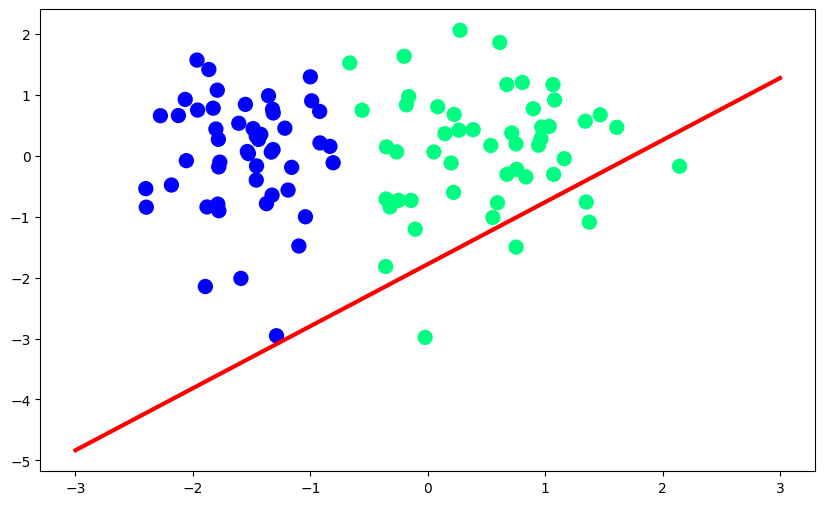

In [60]:
graph(X, y, np.random.randn(3))

In [61]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [62]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

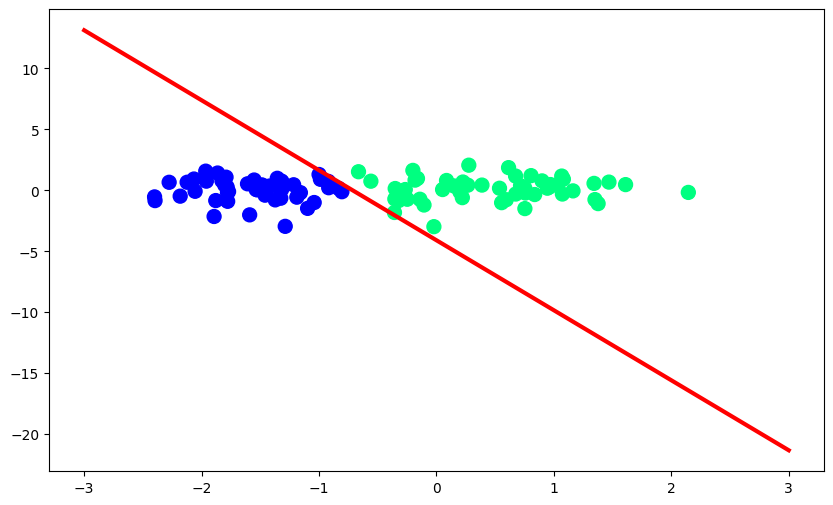

In [63]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# plt.ylim(-3,2)

## animation

In [64]:
# def perceptron_steps(X, y, a):
#   rng = np.random.default_rng(2021)
#   X = np.insert(X, 0, 1, axis=1)
#   w = rng.random(3)
#   m = []
#   b = []
#   for i in range(200):
#     j = np.random.randint(0, 100)
#     y_hat = unit_step(np.dot(X[j], w))

#     w = w - a * (y_hat - y[j]) * X[j]
#     m.append(-(w[1]/ w[2]))
#     b.append(-(w[0]/ w[2]))
#   return m, b
# m, b = perceptron_steps(X,y, 0.1)


In [65]:
# # %matplotlib inline
# from matplotlib.animation import FuncAnimation
# import matplotlib.animation as animation
# from IPython.display import HTML

In [66]:
# fig, ax = plt.subplots(figsize=(9,5))

# x_i = np.arange(-3, 3, 0.1)
# y_i = x_i * m[0] + b[0]
# ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
# line, = ax.plot(x_i, x_i * m[0] + b[0], 'r--', linewidth=2)
# # plt.ylim(-3,3)

# def update(i):
#     label = 'epoch {0}'.format(i + 1)
#     line.set_ydata(x_i * m[i] + b[i])
#     ax.set_xlabel(label)
#     # return line, ax

# anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
# # anim.save('perceptron.gif', writer='imagemagick')
# # plt.show()
# HTML(anim.to_jshtml())  # <-- to show animation


# scratch (perceptron loss method)

In [67]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=15)

In [68]:
X.shape

(100, 2)

In [69]:
y.shape

(100,)

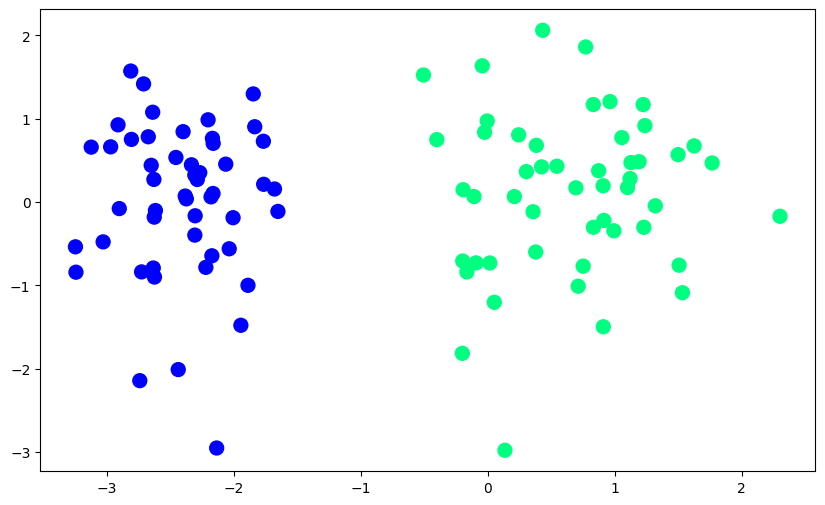

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [71]:
def activation(z):
    return 1 if z>0 else -1

textbook:
```python
def perceptron(X,y, lr = 0.1, epochs = 1000):
    
    w1=w2=b=1
    
    for j in range(epochs):
    
        for i in range(X.shape[0]):

            # check condition
            z = w1*X[i][0] + w2*X[i][1] + b

            if z*y[i] < 0:
                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                b = b + lr*y[i]
            
    return [w1,w2],b
w ,b = perceptron(X, y)
```

In [72]:
def calc_gradients(X, y, w, b):
  dj_dw = np.zeros(2)
  dj_db = 0

  m, n=X.shape
  for i in range(m):
    f_wb = activation(np.dot(w, X[i]) + b)
    if (y[i] * f_wb) >=0:
      dj_db += 0
    else:
      dj_db +=  y[i]

    for j in range(n):
      if (y[i] * f_wb) >=0:
        dj_dw[j] += 0
      else:
        dj_dw[j] +=  y[i]* X[i][j]
  dj_db = dj_db/m
  dj_dw = dj_dw/m
  return dj_db, dj_dw

In [73]:
alpha = 0.01
epochs = 2000

In [74]:
def gradient_descent(X, y, alpha, epochs):
  # rng = np.random.default_rng(2021)
  # w = rng.random(2)
  # b = rng.random()
  w = np.array([1,1])
  b = 1
  # print(w, b)

  for i in range(epochs):
    dj_db, dj_dw = calc_gradients(X, y, w, b)
    w = w + alpha * dj_dw
    b = b + alpha * dj_db
    if (i%10==0 or i<10):
      print(dj_dw)
    #   print(f"w: {w}, b: {b}")
  return w, b

w, b = gradient_descent(X, y, alpha, epochs)

[-0.00183613 -0.06841173]
[-0.00183613 -0.06841173]
[-0.00183613 -0.06841173]
[-0.00183613 -0.06841173]
[-0.00183613 -0.06841173]
[-0.00183613 -0.06841173]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00017823 -0.06001702]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665 -0.04797564]
[-0.00067665

In [75]:
w, b

(array([0.9986332, 0.4565182]), np.float64(1.226999999999975))

```# w, b actual:  ([np.float64(1.006638570722407), np.float64(0.22215119727529098)], np.float64(1.3000000000000003))```

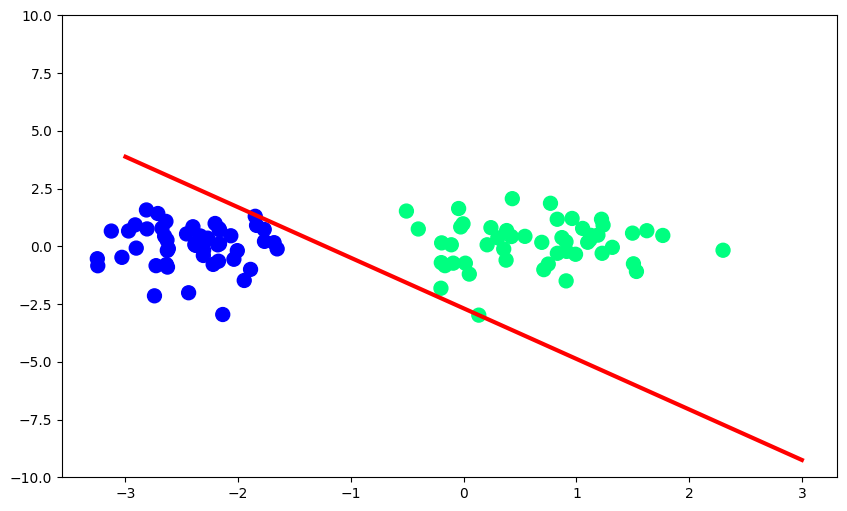

In [76]:
def graph(X, y, w, b):
  intercept_, coef_ = b ,w
  m = -(coef_[0]/coef_[1])
  b = -(intercept_/coef_[1])

  x_input = np.linspace(-3, 3, 100)
  y_input = m*x_input + b

  plt.figure(figsize=(10,6))
  plt.plot(x_input,y_input,color='red',linewidth=3)
  plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
  plt.ylim(-10,10)
  plt.show()
graph(X, y, w, b)

In [77]:
# def perceptron_steps(X, y, alpha, epochs):
#   m_history = []
#   b_history = []
#   rng = np.random.default_rng(2021)
#   # w = rng.random(2)
#   # b = rng.random()
#   w = np.array([1,1])
#   b = 1
#   for i in range(epochs):
#     dj_db, dj_dw = calc_gradients(X, y, w, b)
#     w = w + alpha * dj_dw
#     b = b + alpha * dj_db
#     if (i%10==0):
#       print(f"w: {w}, b: {b}")
#       m_history.append(-(w[0]/ w[1]))
#       b_history.append(-(b/ w[1]))
#   return m_history, b_history
# m_history, b_history = perceptron_steps(X,y, 0.1, 1000)


In [78]:
# # %matplotlib inline
# from matplotlib.animation import FuncAnimation
# import matplotlib.animation as animation
# from IPython.display import HTML

In [79]:
# fig, ax = plt.subplots(figsize=(9,5))

# x_i = np.arange(-3, 3, 0.1)
# y_i = x_i * m_history[0] + b_history[0]
# ax.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
# line, = ax.plot(x_i, x_i * m_history[0] + b_history[0], 'r--', linewidth=2)
# # plt.ylim(-3,3)

# def update(i):
#     label = 'epoch {0}'.format(i + 1)
#     line.set_ydata(x_i * m_history[i] + b_history[i])
#     ax.set_xlabel(label)
#     # return line, ax

# anim = FuncAnimation(fig, update, repeat=False, frames=100, interval=100)
# # anim.save('perceptron.gif', writer='imagemagick')
# # plt.show()
# HTML(anim.to_jshtml())  # <-- to show animation
